Number of Keypoints in Image 1: 907
Number of Keypoints in Image 2: 1471
Total Matches Found: 317


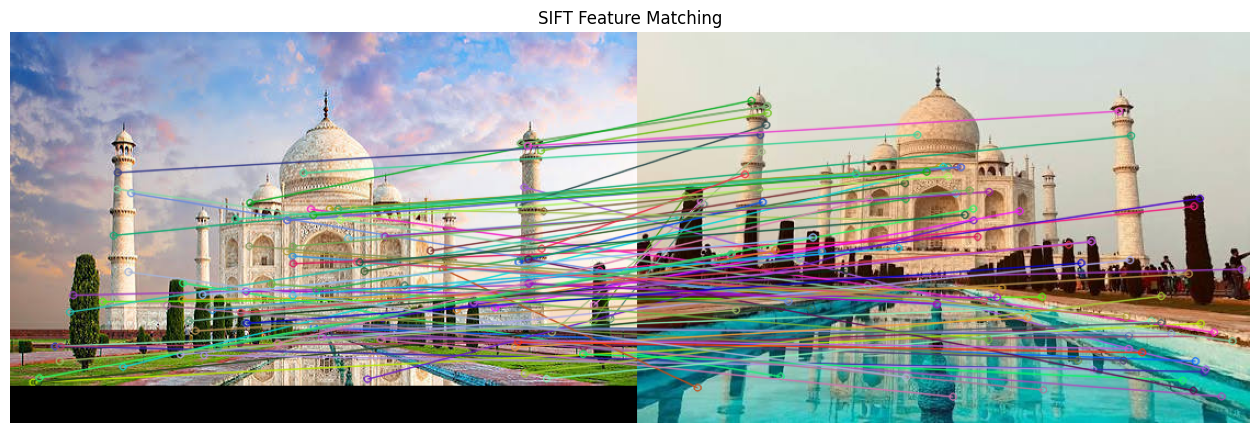

In [3]:
# Install once if needed
# !pip install opencv-contrib-python matplotlib numpy

import cv2
import matplotlib.pyplot as plt

# Read images
image1 = cv2.imread(r"C:\Users\marun\Downloads\taj1.jpg")   # Replace with your image name
image2 = cv2.imread(r"C:\Users\marun\Downloads\taj2.jpg")   # Replace with your image name

if image1 is None or image2 is None:
    print("Error: Check image names or paths.")
else:
    # Convert to grayscale
    gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

    # Create SIFT detector
    sift = cv2.SIFT_create()

    # Detect keypoints and descriptors
    keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

    print("Number of Keypoints in Image 1:", len(keypoints1))
    print("Number of Keypoints in Image 2:", len(keypoints2))

    # Match descriptors using Brute Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(descriptors1, descriptors2)

    # Sort matches by distance
    matches = sorted(matches, key=lambda x: x.distance)

    print("Total Matches Found:", len(matches))

    # Draw only the best 100 matches
    matched_image = cv2.drawMatches(
        image1,
        keypoints1,
        image2,
        keypoints2,
        matches[:100],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Display only the final matched image
    plt.figure(figsize=(16,8))
    plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
    plt.title("SIFT Feature Matching")
    plt.axis("off")
    plt.show()